In [2]:
import numpy as np 
import pandas as pd 
import seaborn as sns 

import statsmodels.api as sm 

from sklearn.datasets import make_regression

In [6]:
# Generate a synthetic dataset with multicollinearity
np.random.seed(42)
X, y = make_regression(n_samples=100, n_features=3, noise=0.5, random_state=42)

# Introduce multicollinearity between columns 0 and 1
X[:, 1] = X[:, 0] + 0.5 * np.random.normal(size=100) 

# Convert data to a pandas DataFrame
data = pd.DataFrame(X, columns=['X1', 'X2', 'X3'])
data['y'] = y

data.sample(5)

,X1,X2,X3,y
30,-0.385082,-0.685936,-0.676922,23.574013
56,-0.309212,-0.728821,0.331263,70.159535
13,0.186454,-0.770186,-0.661786,57.434701
41,-1.062304,-0.976620,0.473592,-90.911746
7,-0.908024,-0.524307,-1.412304,59.140530


<Axes: >

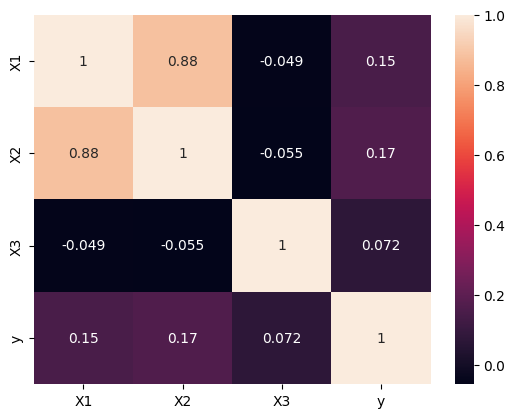

In [7]:
# Using the correlation matrix with heatmap
sns.heatmap(data.corr(), annot=True)

>  As expected, the correlation coefficient of X1 and X2 is greater than 0.8 which indicate the high correlation.                           

In [ ]:
# Using the VIF method
from statsmodels.stats.outliers_influence import variance_inflation_factor

# To store the generated value of VIF
vif = pd.DataFrame()
vif['columns'] = data.columns
 
# Calculating VIF for each feature
vif['VIF'] = [variance_inflation_factor(data.values, i) for i in range(len(data.columns))]

vif

,columns,VIF
0,X1,4.484109
1,X2,4.500593
2,X3,1.009731
3,y,1.034202


> The VIF value of X1 and X2 is greater then 1 as well as far from the 1. Hence it indicate the presence of correlation between the these variables

In [10]:
# Using the condition number which we can get from the OLS summary

# Add a constant term to predictor variable
data_with_constant = sm.add_constant(data)

#Create and fit an OLS  model using all the predictor variables
model_all = sm.OLS(data['y'], data_with_constant).fit()

In [12]:
# Print the summary for the model
print(model_all.summary() )

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.395e+34
Date:                Wed, 18 Mar 2026   Prob (F-statistic):               0.00
Time:                        08:08:31   Log-Likelihood:                 3189.0
No. Observations:                 100   AIC:                            -6368.
Df Residuals:                      95   BIC:                            -6355.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       8.882e-16   3.63e-16      2.450      0.0

> Here the condition number is higher that 100, which indicate the effect of collinearity of the variables.